## Análise de Cluster para Monitoramento de Reator Químico

Neste notebook, vamos simular o monitoramento de um reator químico para detectar anomalias. Geraremos dados fictícios de dois sensores — **Temperatura (°C)** e **Pressão (bar)** — que representam diferentes estados de operação do reator.

Os estados são:
- **Operação Normal:** O estado desejado e mais comum.
- **Anomalia de Aquecimento:** Um desvio onde a temperatura começa a subir, possivelmente por uma falha no sistema de refrigeração.
- **Falha Crítica:** Eventos raros e perigosos onde os parâmetros saem completamente do controle.

O objetivo é usar um algoritmo de clustering para identificar esses diferentes estados a partir dos dados brutos, sem conhecimento prévio dos rótulos.

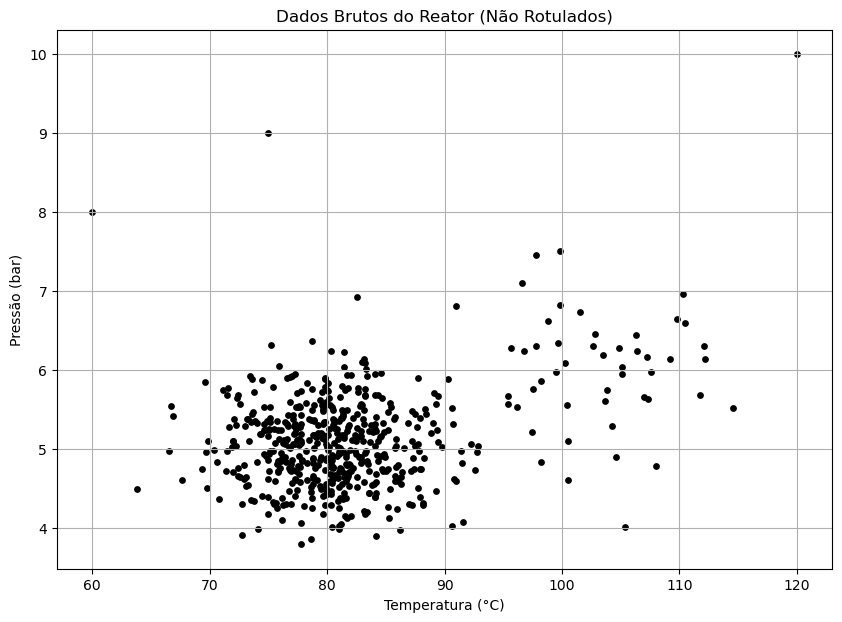

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Semente para reprodutibilidade
np.random.seed(42)

# 1. Gerar dados de Operação Normal
# A maioria dos dados estará aqui, em torno de 80°C e 5 bar
operacao_normal = np.random.randn(500, 2) * [5, 0.5] + [80, 5]

# 2. Gerar dados de Anomalia de Aquecimento
# Temperatura mais alta, pressão ligeiramente elevada
anomalia_aquecimento = np.random.randn(50, 2) * [7, 0.7] + [100, 6]

# 3. Gerar dados de Falha Crítica
# Pontos esporádicos e distantes, representando falhas graves
falha_critica = np.array([[60, 8], [120, 10], [75, 9]])

# Combinar todos os dados em um único dataset
X = np.vstack([operacao_normal, anomalia_aquecimento, falha_critica])

# Visualizar os dados brutos (como um engenheiro os veria)
plt.figure(figsize=(10, 7))
plt.scatter(X[:, 0], X[:, 1], s=15, color='k')
plt.title('Dados Brutos do Reator (Não Rotulados)')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Pressão (bar)')
plt.grid(True)
plt.show()

### Aplicando o Clustering com DBSCAN

Agora, vamos aplicar o `DBSCAN` aos dados. A grande vantagem do DBSCAN aqui é sua capacidade de encontrar os clusters principais e, ao mesmo tempo, **isolar os pontos que não pertencem a nenhum cluster (ruído ou outliers)**. No nosso cenário, esses outliers são exatamente o que queremos identificar como falhas críticas.

Número de clusters encontrados: 2
Pontos de ruído/falha encontrados: 90


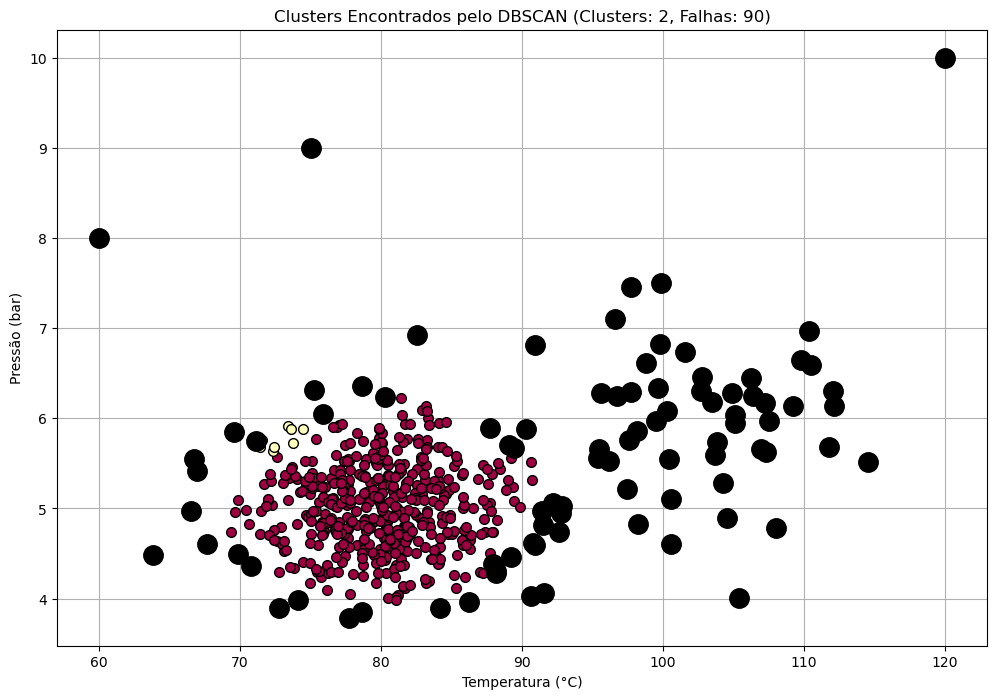

In [2]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# 1. Normalizar os dados
# É crucial para o DBSCAN, que é baseado em distância
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Aplicar o DBSCAN
# Os parâmetros 'eps' e 'min_samples' foram escolhidos empiricamente para este exemplo.
# 'eps' define a vizinhança e 'min_samples' o número de pontos para formar um cluster.
db = DBSCAN(eps=0.3, min_samples=10).fit(X_scaled)

# Extrair os rótulos dos clusters e o número de clusters encontrados
labels = db.labels_
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print(f'Número de clusters encontrados: {n_clusters_}')
print(f'Pontos de ruído/falha encontrados: {n_noise_}')

# 3. Visualizar os resultados
plt.figure(figsize=(12, 8))
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Cor preta para o ruído/falhas
        col = [0, 0, 0, 1]

    class_member_mask = (labels == k)

    xy = X[class_member_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col), markeredgecolor='k', markersize=14 if k == -1 else 7)

plt.title(f'Clusters Encontrados pelo DBSCAN (Clusters: {n_clusters_}, Falhas: {n_noise_})')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Pressão (bar)')
plt.grid(True)
plt.show()

### Interpretação dos Resultados

O algoritmo de clustering conseguiu separar os dados em grupos distintos, que podemos interpretar da seguinte forma no contexto da engenharia de processos:

- **Cluster 0 (Roxo):** Este é o maior grupo e representa a **Operação Normal** do reator. Em um sistema de monitoramento, qualquer nova leitura de sensor que caia dentro desta região seria considerada como um estado saudável e esperado.

- **Cluster 1 (Verde):** O segundo cluster, caracterizado por temperaturas mais altas, representa a **Anomalia de Aquecimento**. O sistema pode ser programado para emitir um alerta de nível 1 (aviso) quando as leituras entram consistentemente nesta zona, sugerindo uma investigação (ex: verificar o sistema de refrigeração).

- **Pontos Pretos (Ruído/Outliers):** Os pontos que não foram atribuídos a nenhum cluster (rótulo `-1`) são as **Falhas Críticas**. Eles representam condições raras e perigosas, muito distantes do comportamento normal. A detecção de um desses pontos acionaria um alarme de nível máximo, exigindo uma ação imediata para garantir a segurança da planta.

Esta análise demonstra como o clustering transforma dados brutos de sensores em **inteligência acionável**, permitindo um monitoramento de processos muito mais sofisticado e preditivo.